# Pakistan Student Employability Analysis

## Data Cleaning, Exploratory Data Analysis, and Documentation Report

### Prepared by
Muhammad Waqar Tahir

---

## Project Description

The dataset is obtained from Kaggle.
This dataset holds academic, skill, and career readiness records for 50,000 Pakistani university students. The goal of this project is to clean the raw data and explore which academic and skill factors relate most to employability outcomes.

In [1]:
# Imports and Global Plot Settings
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"
pd.set_option("display.max_columns", 60)

# Loading the Dataset

The dataset is loaded and its dimensions are checked to confirm a successful import.

In [2]:
df = pd.read_csv("pk_student_employability_dataset.csv")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

Rows: 50000, Columns: 49


# First Look at the Data

In [3]:
df.head()

,student_id,age,gender,city,province,university_name,university_type,degree_program,specialization,current_semester,cgpa,attendance_percentage,english_proficiency,academic_performance_level,programming_skill_level,web_development_skill,ai_ml_skill,data_science_skill,cybersecurity_skill,mobile_app_dev_skill,cloud_computing_skill,ui_ux_skill,github_usage,linkedin_presence,ai_tools_usage,chatgpt_usage_frequency,kaggle_activity,open_source_contributions,internship_experience,number_of_internships,freelancing_experience,monthly_freelancing_income_pkr,certifications_count,hackathon_participation,communication_skill,teamwork_skill,leadership_skill,problem_solving_skill,time_management_skill,expected_salary_pkr,job_readiness_score,employability_status,preferred_career_path,likely_to_get_hired,remote_work_interest,daily_study_hours,internet_quality,device_type,social_media_usage_hours
0,PKSTU00001,21,Male,Lahore,Punjab,University of Peshawar,Public,Information Technology,Cloud IT,2,2.64,79.6,Intermediate,Average,Intermediate,Intermediate,Intermediate,Expert,Beginner,Beginner,NaN,Beginner,Never,Very Active,Often,Sometimes,Never,10+ contributions,Yes,1,Yes,49975.0,2.0,0,Average,Excellent,Average,Average,Good,33000,100.0,Highly Employable,IT Manager,Yes,Neutral,3.8,Average,Smartphone Only,3.3
1,PKSTU00002,22,Female,Faisalabad,Punjab,COMSATS,Public,Information Technology,ERP Systems,3,1.82,66.6,Upper-Intermediate,Poor,Beginner,Advanced,NaN,Intermediate,Intermediate,Beginner,Advanced,Advanced,Often,Basic Profile,Often,Sometimes,Often,1 contribution,Yes,1,No,0.0,4.0,0,Excellent,Average,Below Average,Excellent,Average,76000,100.0,Highly Employable,Network Engineer,Yes,Slightly Interested,4.4,Average,Laptop,5.5
2,PKSTU00003,24,Female,Quetta,Balochistan,Air University,Public,Computer Science,Theory of Computation,3,3.62,78.5,Upper-Intermediate,Distinction,Expert,Intermediate,Intermediate,Intermediate,NaN,NaN,Beginner,Intermediate,Sometimes,Basic Profile,Daily,Daily,Daily,1 contribution,Yes,1,Yes,20602.0,1.0,0,Good,Good,Excellent,Average,Below Average,50000,100.0,Highly Employable,Web Developer,Yes,Interested,7.5,Poor,Desktop,3.0
3,PKSTU00004,20,Male,Faisalabad,Punjab,UET Lahore,Public,Computer Science,General,2,3.44,NaN,Intermediate,High,Advanced,Intermediate,Intermediate,Expert,Expert,Beginner,Intermediate,Intermediate,Rarely,NaN,Often,Often,Sometimes,2-5 contributions,No,0,No,0.0,0.0,2,Below Average,Excellent,Average,Below Average,Average,101000,94.8,Highly Employable,Web Developer,Yes,Very Interested,6.9,Good,Laptop,4.7
4,PKSTU00005,19,Female,Sargodha,Punjab,COMSATS,Public,Artificial Intelligence,Computer Vision,7,3.24,67.1,Intermediate,High,Intermediate,NaN,Expert,Beginner,Beginner,Beginner,Intermediate,Intermediate,Often,NaN,Sometimes,Rarely,Sometimes,5-10 contributions,Yes,1,No,0.0,1.0,0,Poor,Excellent,Average,Excellent,Average,81000,88.8,Highly Employable,AI/ML Engineer,Yes,Interested,5.5,Excellent,Laptop,2.9


# Structure and Data Types

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 49 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   student_id                      50000 non-null  object 
 1   age                             50000 non-null  int64  
 2   gender                          50000 non-null  object 
 3   city                            50000 non-null  object 
 4   province                        50000 non-null  object 
 5   university_name                 50000 non-null  object 
 6   university_type                 50000 non-null  object 
 7   degree_program                  50000 non-null  object 
 8   specialization                  50000 non-null  object 
 9   current_semester                50000 non-null  int64  
 10  cgpa                            48995 non-null  float64
 11  attendance_percentage           48814 non-null  float64
 12  english_proficiency             

# Numeric Summary

In [5]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
age,50000.0,21.02,2.16,17.0,20.00,21.00,22.00,31.0
current_semester,50000.0,4.49,2.29,1.0,2.00,4.00,6.00,8.0
cgpa,48995.0,2.91,0.52,1.5,2.56,2.92,3.27,4.0
attendance_percentage,48814.0,77.64,13.30,30.0,68.60,78.00,87.40,100.0
number_of_internships,50000.0,0.98,1.09,0.0,0.00,1.00,2.00,4.0
monthly_freelancing_income_pkr,49536.0,17098.34,34659.08,0.0,0.00,0.00,20821.00,300000.0
certifications_count,48976.0,1.07,1.04,0.0,0.00,1.00,2.00,7.0
hackathon_participation,50000.0,0.57,0.76,0.0,0.00,0.00,1.00,5.0
expected_salary_pkr,50000.0,75966.24,26719.38,25000.0,57000.00,73000.00,92000.00,228000.0
job_readiness_score,50000.0,93.05,12.52,10.1,90.00,100.00,100.00,100.0


# Data Cleaning

The raw data is checked and fixed for the following issues, in order:

- Missing values
- Duplicate records
- Inconsistent categorical entries

## Missing Values

Only columns with missing values are listed below, along with their missing percentage.

In [6]:
missing = df.isnull().sum()
missing = missing[missing > 0]
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({"Missing Values": missing, "Percentage": missing_pct})
missing_df.sort_values("Percentage", ascending=False)

,Missing Values,Percentage
open_source_contributions,20841,41.68
ui_ux_skill,9149,18.30
mobile_app_dev_skill,8915,17.83
cybersecurity_skill,8344,16.69
ai_ml_skill,6417,12.83
data_science_skill,6288,12.58
cloud_computing_skill,6234,12.47
linkedin_presence,5998,12.00
web_development_skill,5454,10.91
programming_skill_level,3310,6.62


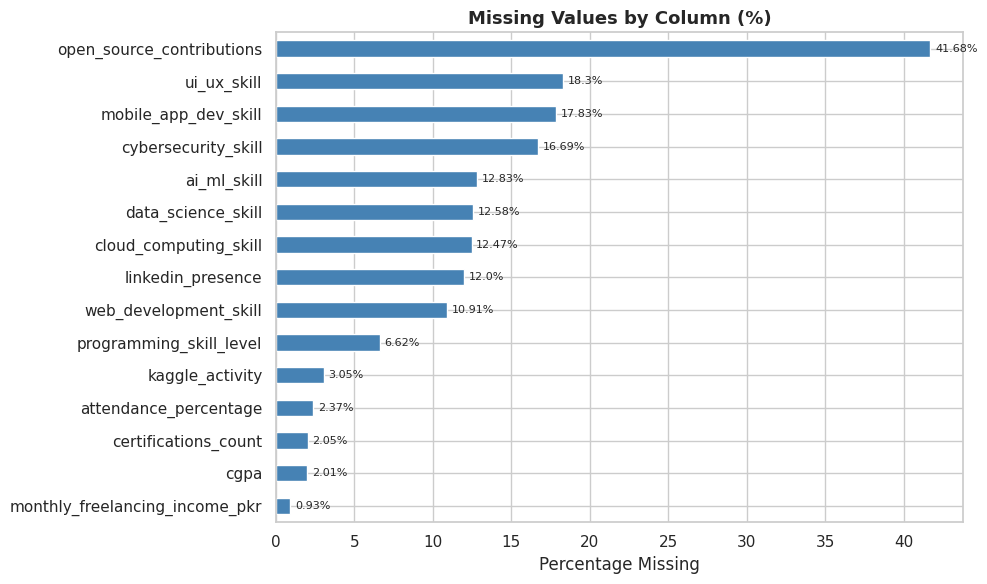

In [7]:
plt.figure(figsize=(10, 6))
ax = missing_pct.sort_values().plot(kind="barh", color="steelblue")
plt.title("Missing Values by Column (%)")
plt.xlabel("Percentage Missing")
for i, v in enumerate(missing_pct.sort_values()):
    ax.text(v + 0.3, i, f"{v}%", va="center", fontsize=8)
plt.tight_layout()
plt.show()

### Observation

`open_source_contributions` has the highest share of missing data at 41.68 percent, followed by skill-level columns such as `ui_ux_skill` at 18.30 percent and `mobile_app_dev_skill` at 17.83 percent. `cgpa` and `attendance_percentage` are only missing in about 2 percent of rows.

## Handling Missing Values

The missing values follow clear patterns, so each group is treated differently:

- `cgpa` and `attendance_percentage`: dropped, since the missing share is small
- Skill-level columns and `linkedin_presence`: filled with "Not Assessed", since a blank likely means the skill was never evaluated
- `kaggle_activity`: filled with "Never"
- `open_source_contributions`: filled with "No Contributions"
- `certifications_count`: filled with 0
- `monthly_freelancing_income_pkr`: filled with the median income of students who freelance

In [7]:
df = df.dropna(subset=["cgpa", "attendance_percentage"]).reset_index(drop=True)

skill_cols = ["programming_skill_level", "web_development_skill", "ai_ml_skill",
              "data_science_skill", "cybersecurity_skill", "mobile_app_dev_skill",
              "cloud_computing_skill", "ui_ux_skill", "linkedin_presence"]
df[skill_cols] = df[skill_cols].fillna("Not Assessed")

df["kaggle_activity"] = df["kaggle_activity"].fillna("Never")
df["open_source_contributions"] = df["open_source_contributions"].fillna("No Contributions")
df["certifications_count"] = df["certifications_count"].fillna(0)

freelancer_median = df.loc[df["freelancing_experience"] == "Yes", "monthly_freelancing_income_pkr"].median()
df["monthly_freelancing_income_pkr"] = df["monthly_freelancing_income_pkr"].fillna(freelancer_median)

print("Missing values remaining:", df.isnull().sum().sum())

Missing values remaining: 0


## Duplicate Records

In [8]:
duplicates = df.duplicated().sum()
print(f"Duplicate Records: {duplicates}")

if duplicates > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print("Duplicates removed.")

Duplicate Records: 0


## Verify Cleaning

The cleaned dataset is checked one final time before analysis.

In [9]:
print(f"Final Shape: {df.shape}")
print(f"Remaining Missing Values: {df.isnull().sum().sum()}")
print(f"Remaining Duplicates: {df.duplicated().sum()}")

Final Shape: (47839, 49)
Remaining Missing Values: 0
Remaining Duplicates: 0


Remaining Duplicates: 0


# Exploratory Data Analysis

The cleaned dataset is now explored to understand student demographics, academic performance, skills, and how they relate to employability outcomes.

## Age and Gender

Students range from 17 to 31 years old, with an average age of about 21.

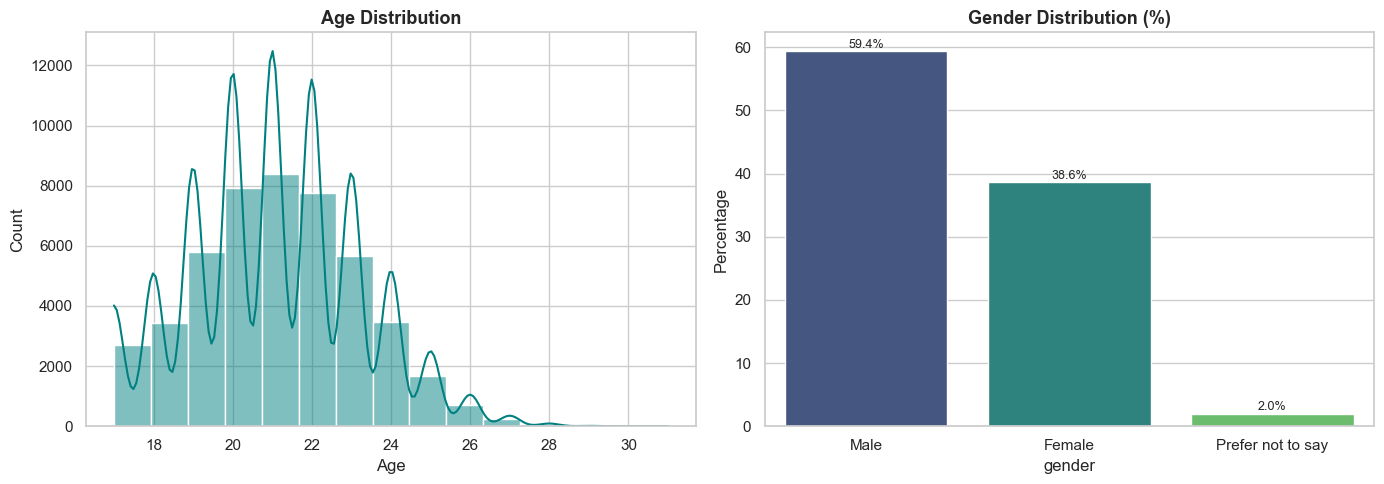

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df, x="age", bins=15, kde=True, ax=axes[0], color="teal")
axes[0].set_title("Age Distribution")
axes[0].set_xlabel("Age")

gender_pct = (df["gender"].value_counts(normalize=True) * 100).round(1)
sns.barplot(x=gender_pct.index, y=gender_pct.values, ax=axes[1], palette="viridis")
axes[1].set_title("Gender Distribution (%)")
axes[1].set_ylabel("Percentage")
for i, v in enumerate(gender_pct.values):
    axes[1].text(i, v + 0.5, f"{v}%", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

### Observation

The sample is 59.4 percent male, 38.6 percent female, and 2.0 percent preferred not to disclose gender.

## Province-wise Distribution

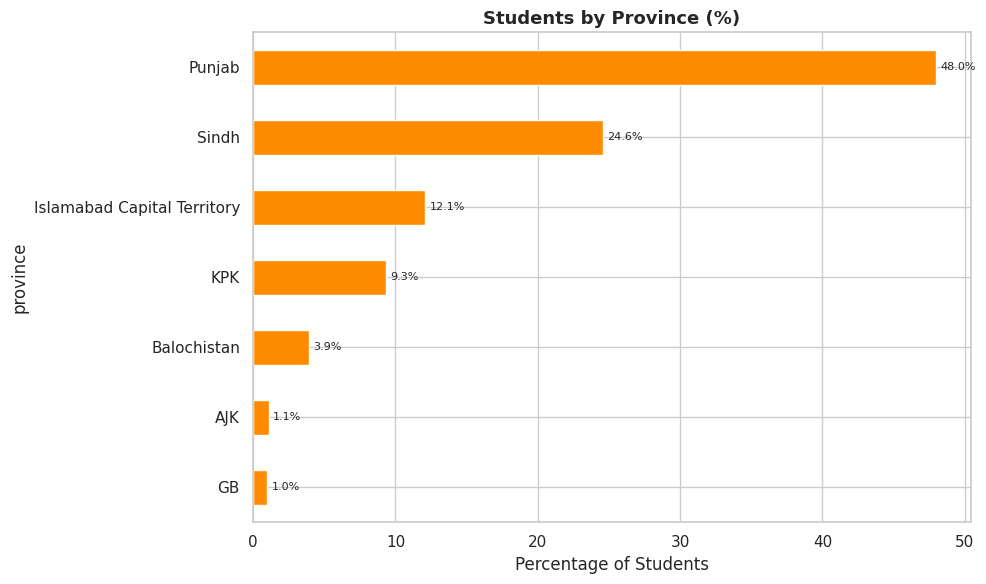

In [12]:
province_pct = (df["province"].value_counts(normalize=True) * 100).round(1)

plt.figure(figsize=(10, 6))
ax = province_pct.sort_values().plot(kind="barh", color="darkorange")
plt.title("Students by Province (%)")
plt.xlabel("Percentage of Students")
for i, v in enumerate(province_pct.sort_values()):
    ax.text(v + 0.3, i, f"{v}%", va="center", fontsize=8)
plt.tight_layout()
plt.show()

### Observation

Punjab accounts for 48.1 percent of students, followed by Sindh at 24.6 percent. Together these two provinces represent nearly three-quarters of the sample.

## CGPA Distribution

CGPA is scored on a 4-point scale.

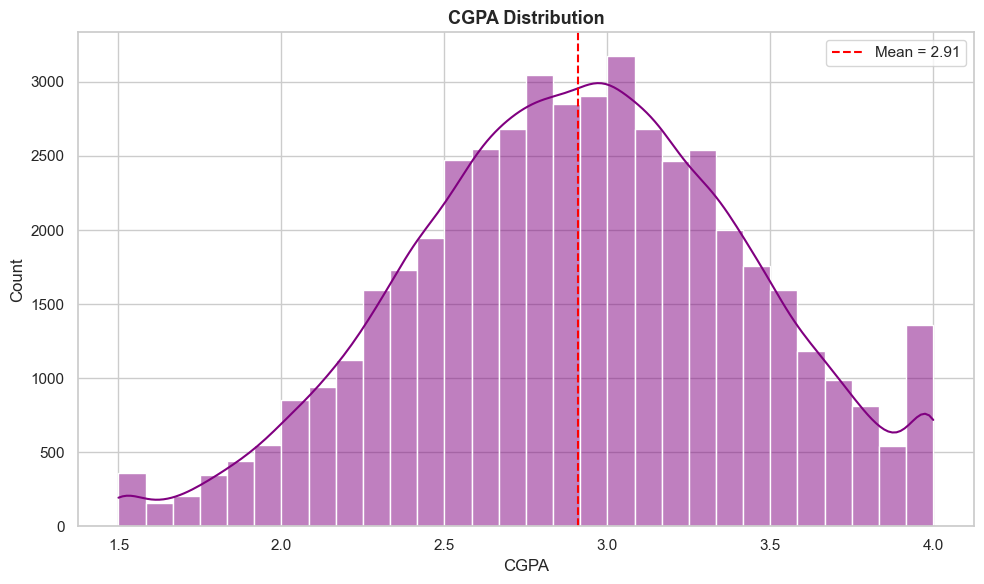

In [12]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x="cgpa", bins=30, kde=True, color="purple")
plt.title("CGPA Distribution")
plt.xlabel("CGPA")
plt.axvline(df["cgpa"].mean(), color="red", linestyle="--", label=f"Mean = {df['cgpa'].mean():.2f}")
plt.legend()
plt.tight_layout()
plt.show()

### Observation

The average CGPA is 2.91 out of 4, with the distribution fairly centered around that value.

## CGPA by Employability Status

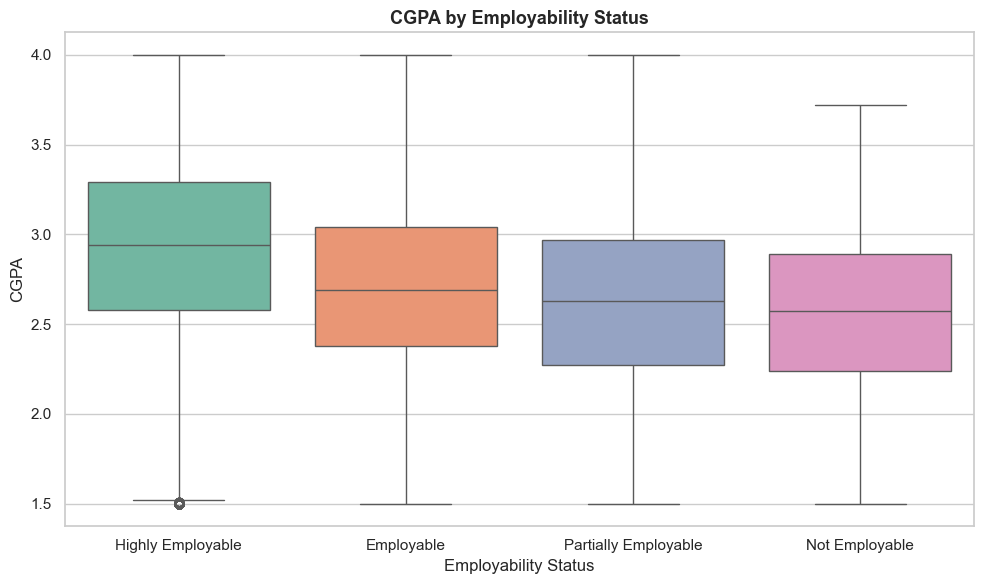

In [13]:
plt.figure(figsize=(10, 6))
order = df.groupby("employability_status")["cgpa"].median().sort_values(ascending=False).index
sns.boxplot(data=df, x="employability_status", y="cgpa", order=order, palette="Set2")
plt.title("CGPA by Employability Status")
plt.xlabel("Employability Status")
plt.ylabel("CGPA")
plt.tight_layout()
plt.show()

### Observation

Students rated as Highly Employable tend to hold a higher median CGPA than students in the lower employability categories.

## Programming Skill Level vs Employability

The share of each employability category is compared across programming skill levels.

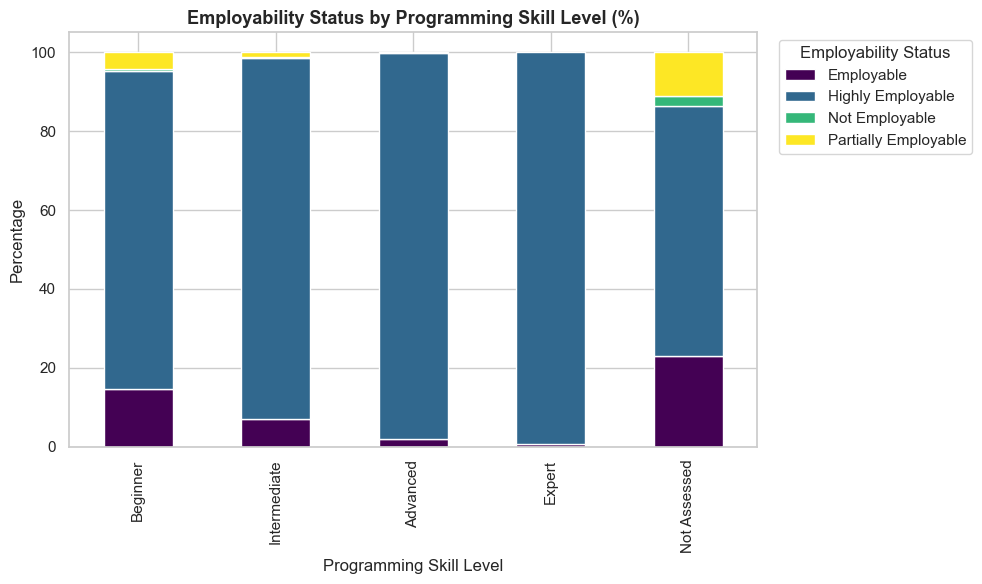

In [14]:
ct = pd.crosstab(df["programming_skill_level"], df["employability_status"], normalize="index") * 100
ct = ct.round(1).reindex(["Beginner", "Intermediate", "Advanced", "Expert", "Not Assessed"]).dropna(how="all")

ct.plot(kind="bar", stacked=True, figsize=(10, 6), colormap="viridis")
plt.title("Employability Status by Programming Skill Level (%)")
plt.xlabel("Programming Skill Level")
plt.ylabel("Percentage")
plt.legend(title="Employability Status", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Observation

Highly Employable is the majority outcome across every skill level, but Beginner-level programmers show the largest share of Employable, Partially Employable, and Not Employable outcomes compared to Advanced and Expert programmers.

## Internship Experience and Employability

In [15]:
ct2 = pd.crosstab(df["internship_experience"], df["employability_status"], normalize="index") * 100
ct2 = ct2.round(1)
ct2

employability_status,Employable,Highly Employable,Not Employable,Partially Employable
internship_experience,,,,
No,10.7,85.4,0.6,3.4
Yes,2.8,96.6,0.1,0.5


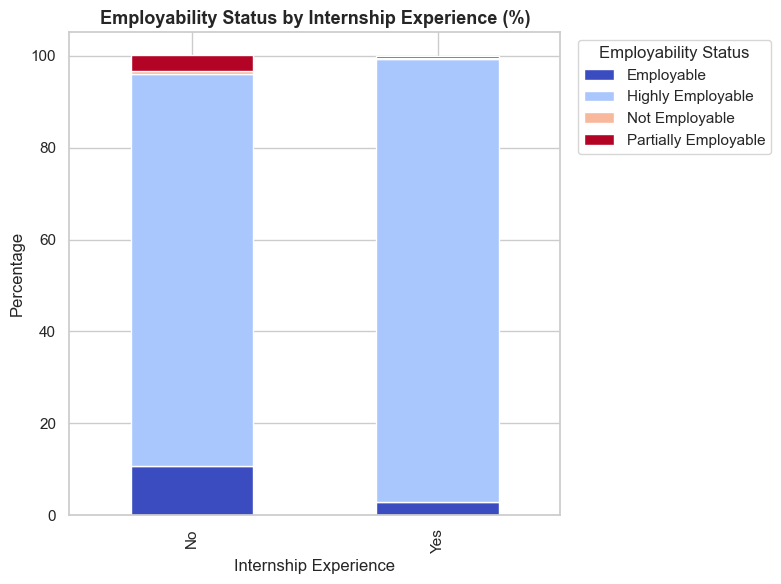

In [16]:
ct2.plot(kind="bar", stacked=True, figsize=(8, 6), colormap="coolwarm")
plt.title("Employability Status by Internship Experience (%)")
plt.xlabel("Internship Experience")
plt.ylabel("Percentage")
plt.legend(title="Employability Status", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Observation

Students without internship experience show a higher combined share of Employable, Partially Employable, and Not Employable outcomes than students who completed at least one internship.

## Job Readiness Score

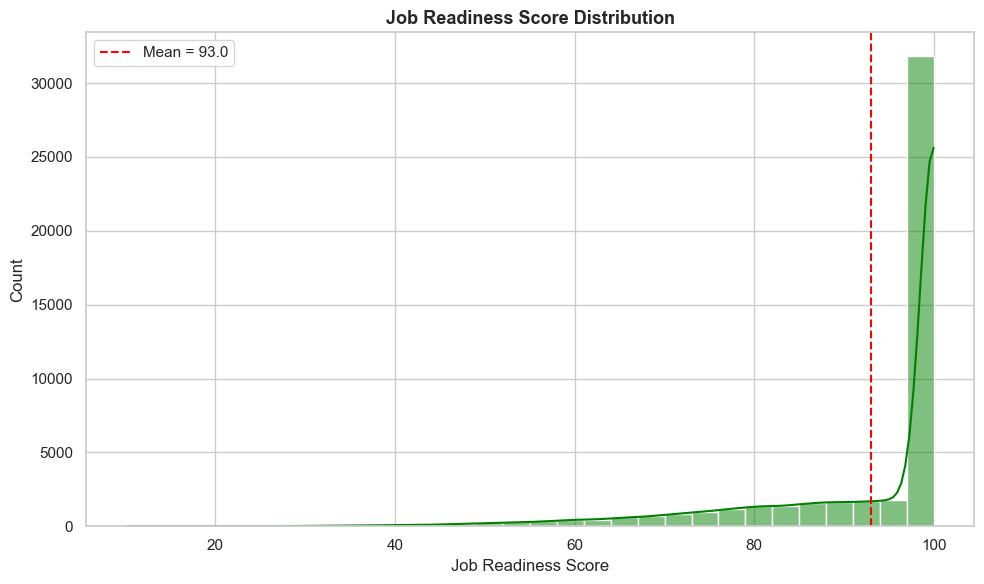

In [17]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x="job_readiness_score", bins=30, kde=True, color="green")
plt.title("Job Readiness Score Distribution")
plt.xlabel("Job Readiness Score")
plt.axvline(df["job_readiness_score"].mean(), color="red", linestyle="--",
            label=f"Mean = {df['job_readiness_score'].mean():.1f}")
plt.legend()
plt.tight_layout()
plt.show()

### Observation

The average job readiness score is 93.1 out of 100, and the median score sits at the maximum value of 100, showing that most students are rated as fully job ready.

## Expected Salary by Employability Status

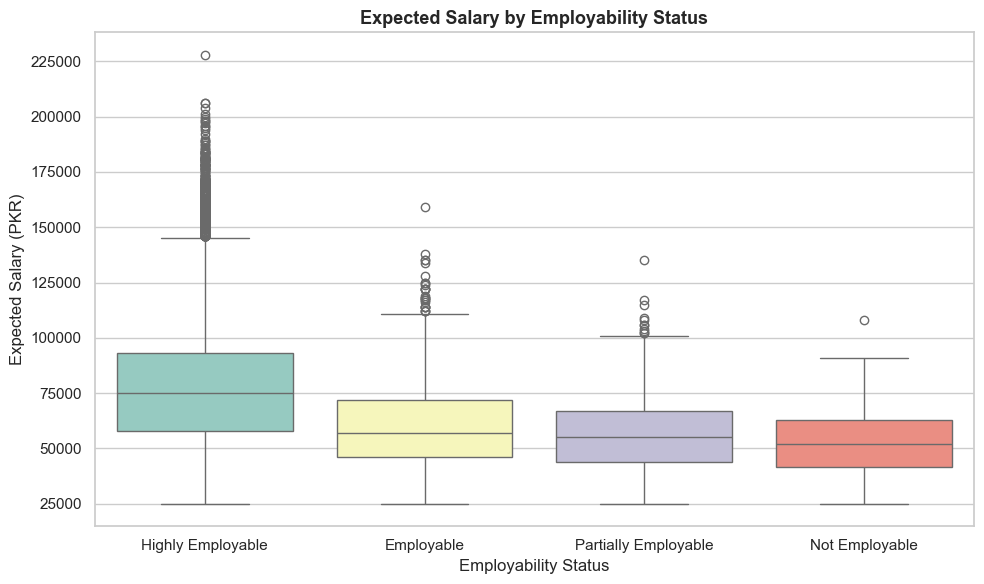

In [18]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="employability_status", y="expected_salary_pkr", order=order, palette="Set3")
plt.title("Expected Salary by Employability Status")
plt.xlabel("Employability Status")
plt.ylabel("Expected Salary (PKR)")
plt.tight_layout()
plt.show()

### Observation

The average expected salary across all students is about 75,966 PKR per month, with the middle 50 percent of students expecting between 57,000 and 92,000 PKR.

## Correlation Among Numeric Features

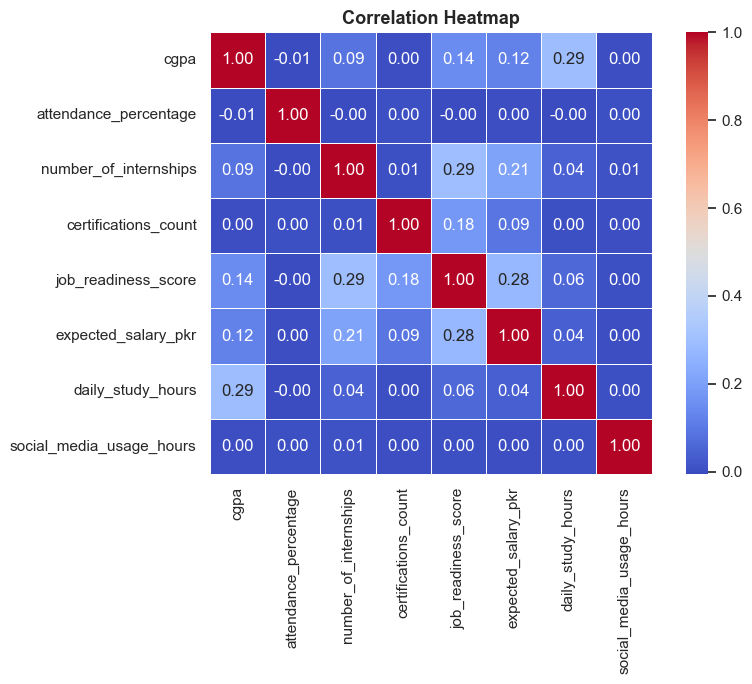

In [19]:
numeric_cols = ["cgpa", "attendance_percentage", "number_of_internships",
                 "certifications_count", "job_readiness_score",
                 "expected_salary_pkr", "daily_study_hours", "social_media_usage_hours"]

plt.figure(figsize=(9, 7))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, square=True)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

### Observation

None of the numeric features show a strong linear relationship with each other, which suggests that employability in this dataset is driven more by categorical factors such as skills, internships, and academic performance level than by simple numeric correlation.

## Employability Status Overview

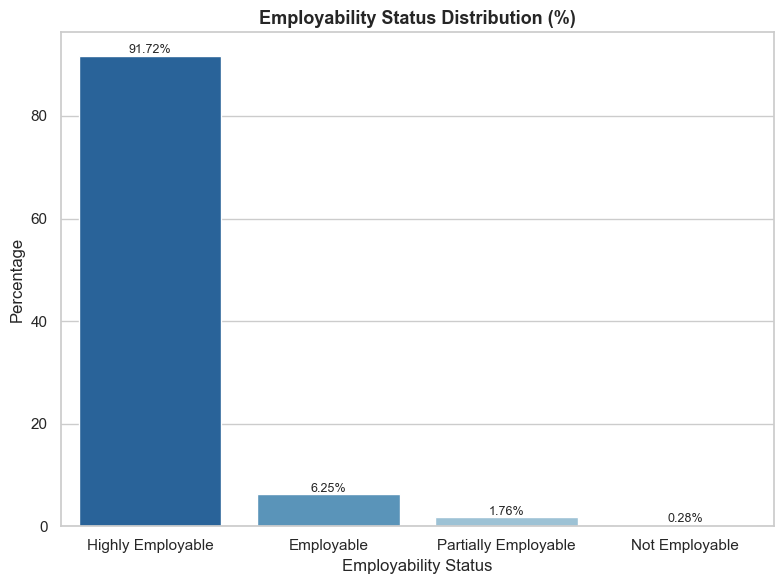

In [20]:
status_pct = (df["employability_status"].value_counts(normalize=True) * 100).round(2)

plt.figure(figsize=(8, 6))
ax = sns.barplot(x=status_pct.index, y=status_pct.values, order=order, palette="Blues_r")
plt.title("Employability Status Distribution (%)")
plt.xlabel("Employability Status")
plt.ylabel("Percentage")
for i, v in enumerate(status_pct.reindex(order).values):
    ax.text(i, v + 0.5, f"{v}%", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

### Observation

91.73 percent of students are rated Highly Employable, 6.26 percent Employable, 1.74 percent Partially Employable, and only 0.27 percent Not Employable.

# Documentation Report

## Summary of Findings

- The cleaned dataset contains 47,839 student records across 49 features, after removing rows with missing CGPA or attendance and filling the remaining gaps based on their likely meaning.
- Students are mostly aged 17 to 31, with an average age of 21, and are drawn mainly from Punjab and Sindh.
- Average CGPA is 2.91 out of 4, and higher CGPA is associated with a Highly Employable rating.
- Programming skill level and internship experience both show a clear link to employability, with stronger skills and prior internships associated with better outcomes.
- The average job readiness score is 93.1 out of 100, and most students are rated as fully job ready.
- Expected salary averages about 75,966 PKR per month and rises with employability status.
- Numeric features show weak correlation with each other, indicating employability depends more on categorical and skill-based factors.

## Recommendations

1. Encourage students with weaker programming skills to pursue structured upskilling, since skill level tracks closely with employability.
2. Promote internship placement programs, as internship experience is linked to stronger employability outcomes.
3. Track certifications and open-source or freelancing activity going forward, since these fields had high missing rates and may hold predictive value once consistently recorded.
4. Use employability status alongside job readiness score to prioritize students who need additional career support.

## Conclusion

This project cleaned a 50,000-record dataset of Pakistani university students and explored how academic performance, skills, and career-readiness activities relate to employability. Highly Employable students tend to combine stronger academics, more advanced skills, and internship exposure, giving universities and career centers a clear basis for targeted support.

# Export Cleaned Dataset

The cleaned dataset is saved for future analysis or modeling.

In [22]:
df.to_csv("pk_student_employability_cleaned.csv", index=False)
print("Cleaned dataset exported successfully.")

Cleaned dataset exported successfully.


# End of Project

Thank you for reviewing this project. This notebook covered data cleaning, exploratory data analysis, and a documentation report for the Pakistan student employability dataset.